In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score


In [20]:
# load and view the data
data = pd.read_csv("Human activity.csv")

# drop subject column at the second last column
data = data.drop(data.columns[-2], axis = 1)
data.head(n=10)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,STANDING
5,0.277199,-0.010098,-0.105137,-0.997335,-0.990487,-0.995420,-0.997627,-0.990218,-0.995549,-0.942469,...,-0.545410,-0.844619,0.082632,-0.143439,0.275041,-0.368224,-0.849632,0.184823,-0.042126,STANDING
6,0.279454,-0.019641,-0.110022,-0.996921,-0.967186,-0.983118,-0.997003,-0.966097,-0.983116,-0.940987,...,-0.217198,-0.564430,-0.212754,-0.230622,0.014637,-0.189512,-0.852150,0.182170,-0.043010,STANDING
7,0.277432,-0.030488,-0.125360,-0.996559,-0.966728,-0.981585,-0.996485,-0.966313,-0.982982,-0.940987,...,-0.082307,-0.421715,-0.020888,0.593996,-0.561871,0.467383,-0.851017,0.183779,-0.041976,STANDING
8,0.277293,-0.021751,-0.120751,-0.997328,-0.961245,-0.983672,-0.997596,-0.957236,-0.984379,-0.940598,...,-0.269401,-0.572995,0.012954,0.080936,-0.234313,0.117797,-0.847971,0.188982,-0.037364,STANDING
9,0.280586,-0.009960,-0.106065,-0.994803,-0.972758,-0.986244,-0.995405,-0.973663,-0.985642,-0.940028,...,0.339526,0.140452,-0.020590,-0.127730,-0.482871,-0.070670,-0.848294,0.190310,-0.034417,STANDING


In [21]:
# separate the data into features and targets (the last column)
target = data.iloc[:, -1] # activity column
features = data.iloc[:, :-1]

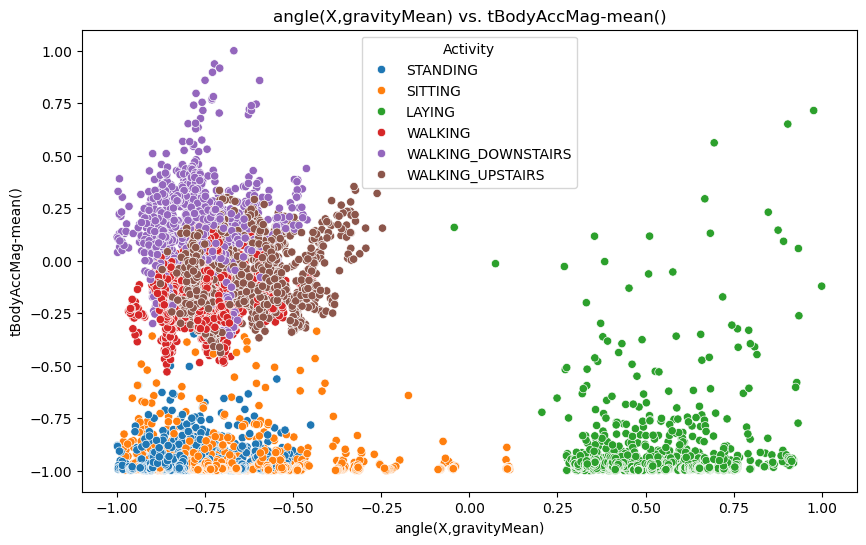

In [22]:
# create a new dataframe with the required columns
new_data = pd.DataFrame()
new_data['angle(X,gravityMean)'] = features['angle(X,gravityMean)']
new_data['tBodyAccMag-mean()'] = features['tBodyAccMag-mean()']
new_data['Activity'] = target

# scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='angle(X,gravityMean)', y='tBodyAccMag-mean()', hue='Activity', data=new_data)
plt.title('angle(X,gravityMean) vs. tBodyAccMag-mean()')
plt.xlabel('angle(X,gravityMean)')
plt.ylabel('tBodyAccMag-mean()')
plt.show()

new_data = new_data.drop('Activity', axis=1)

In [23]:
# standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# encoded the target column
label_encoder = LabelEncoder()
target_label = label_encoder.fit_transform(target)

KMeans Cluster:
[[-0.74802428 -0.95829744]
 [-0.72245738 -0.04471589]
 [ 0.49919599 -0.93635537]]
334.4921987773944


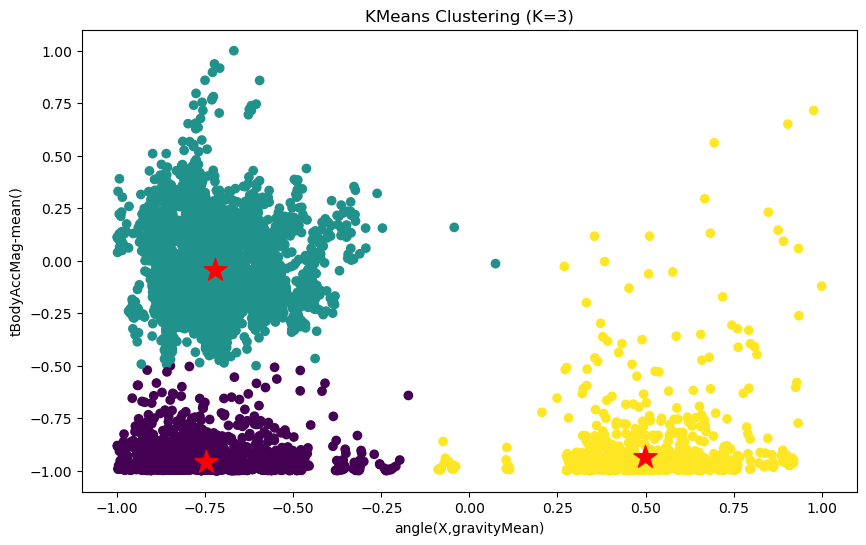


KMedoids Cluster:
[[-0.73957584  0.13018951]
 [-0.64988656 -0.97293097]
 [-0.7360151  -0.1730461 ]]
2589.686848634561


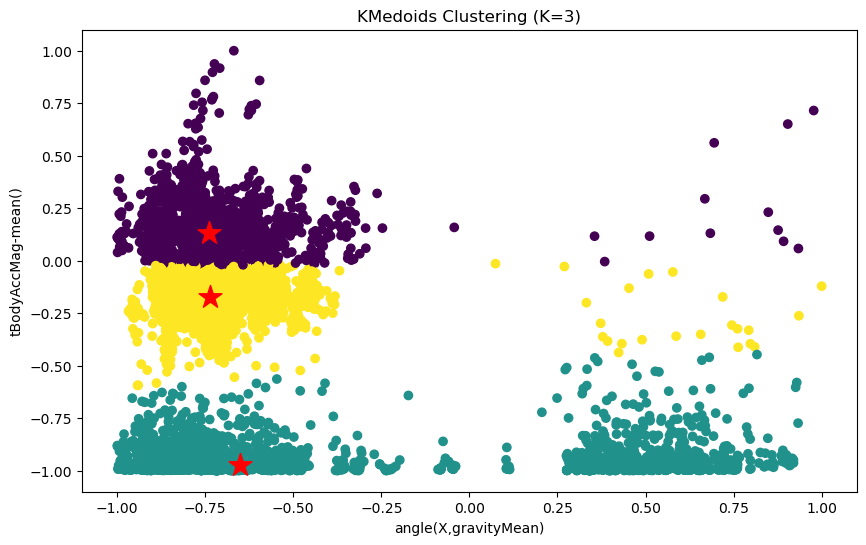

In [24]:
def Kmeans_cluster_n(n, features_scaled, data):
    # KMeans clustering
    kmeans_cluster = KMeans(n_clusters= n, random_state= 22, n_init='auto').fit(features_scaled)
    y_predicted_km = kmeans_cluster.fit_predict(data)
    print("KMeans Cluster:")
    print(kmeans_cluster.cluster_centers_)
    print(kmeans_cluster.inertia_)

    plt.figure(figsize=(10, 6))
    plt.scatter(data['angle(X,gravityMean)'], data['tBodyAccMag-mean()'], c=y_predicted_km, cmap='viridis')
    plt.scatter(kmeans_cluster.cluster_centers_[:, 0], kmeans_cluster.cluster_centers_[:, 1], s=300, c='red', marker='*') # Changed marker to * for better visibility
    plt.title(f'KMeans Clustering (K={n})')
    plt.xlabel('angle(X,gravityMean)')
    plt.ylabel('tBodyAccMag-mean()')
    plt.show()

    kmedoid_cluster = KMedoids(n_clusters= n, random_state= 22).fit(features_scaled)
    y_predicted_kmedoid = kmedoid_cluster.fit_predict(data)
    print("\nKMedoids Cluster:")
    print(kmedoid_cluster.cluster_centers_)
    print(kmedoid_cluster.inertia_)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(data['angle(X,gravityMean)'], data['tBodyAccMag-mean()'], c=y_predicted_kmedoid, cmap='viridis')
    plt.scatter(kmedoid_cluster.cluster_centers_[:, 0], kmedoid_cluster.cluster_centers_[:, 1], s=300, c='red', marker='*') # Changed marker to * for better visibility
    plt.title(f'KMedoids Clustering (K={n})')
    plt.xlabel('angle(X,gravityMean)')
    plt.ylabel('tBodyAccMag-mean()')
    plt.show()

Kmeans_cluster_n(3, features_scaled, new_data)

KMeans Cluster:
[[-0.29998306 -0.95533349]
 [-0.71862997 -0.04665947]]
1779.3560558387846


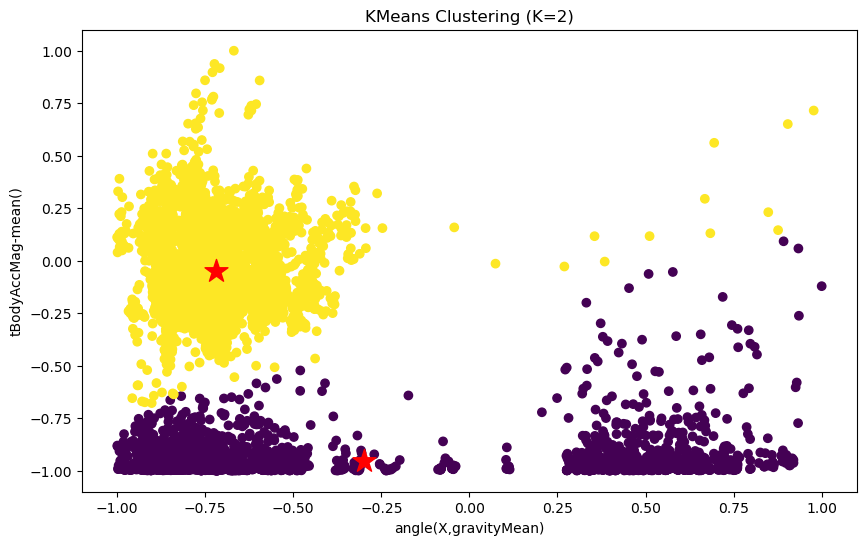


KMedoids Cluster:
[[-0.72693856 -0.06464965]
 [-0.64988656 -0.97293097]]
2784.1755811412136


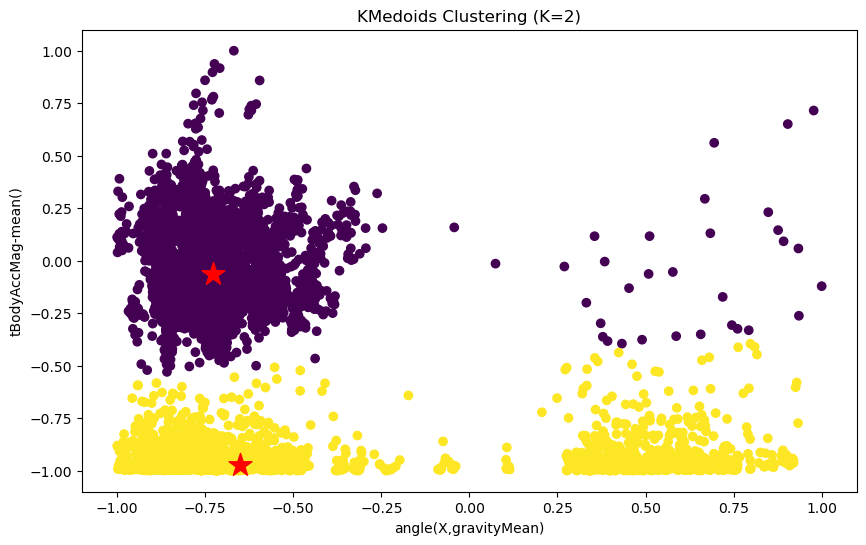

KMeans Cluster:
[[-0.74802428 -0.95829744]
 [-0.72245738 -0.04471589]
 [ 0.49919599 -0.93635537]]
334.4921987773944


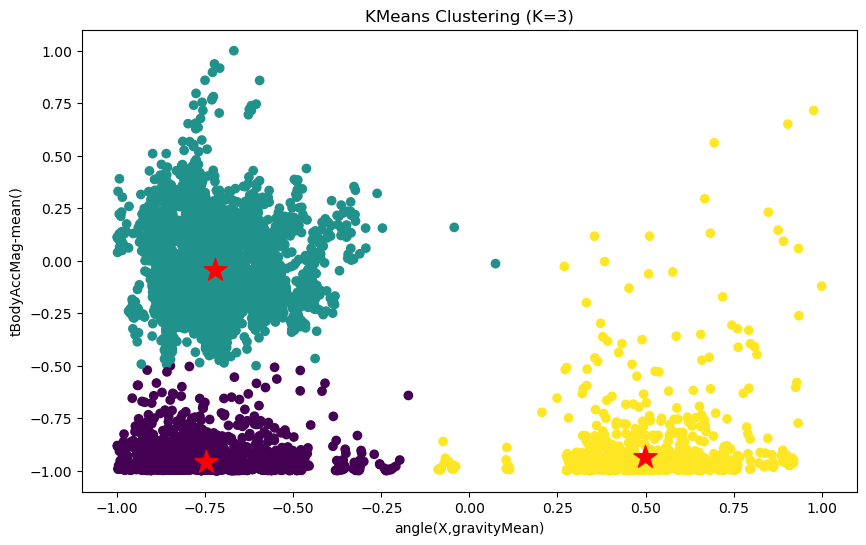


KMedoids Cluster:
[[-0.73957584  0.13018951]
 [-0.64988656 -0.97293097]
 [-0.7360151  -0.1730461 ]]
2589.686848634561


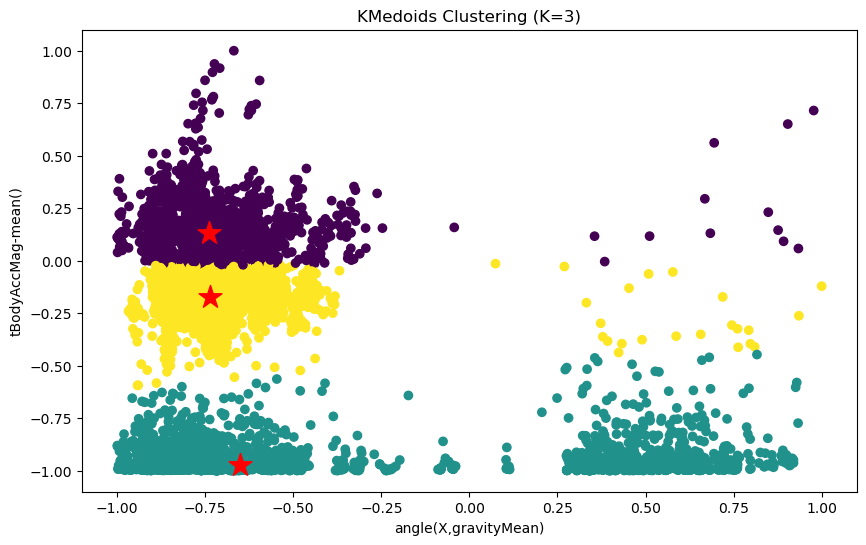

KMeans Cluster:
[[-0.82971321 -0.95568257]
 [-0.72238786 -0.04430592]
 [ 0.5135086  -0.93519253]
 [-0.55950594 -0.96285554]]
296.2498662803639


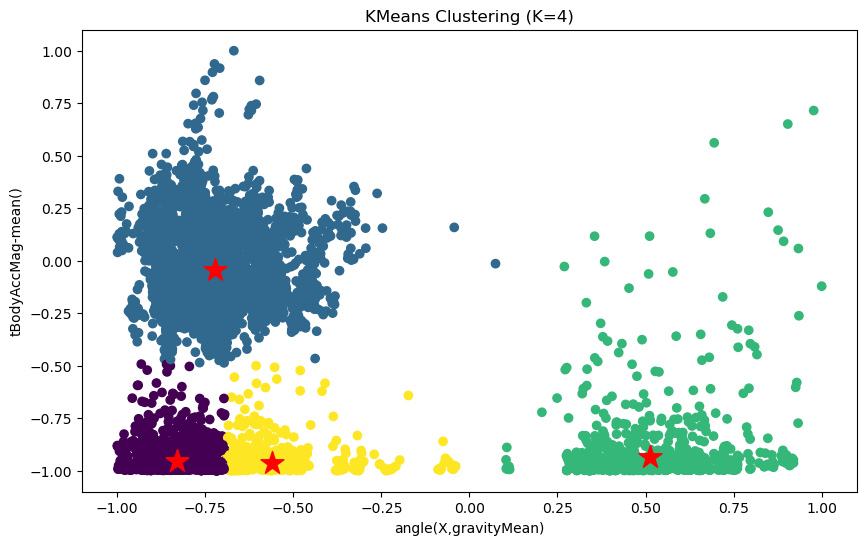


KMedoids Cluster:
[[ 0.50190453 -0.96669875]
 [-0.73957584  0.13018951]
 [-0.7360151  -0.1730461 ]
 [-0.77583114 -0.97300944]]
1059.7862891230425


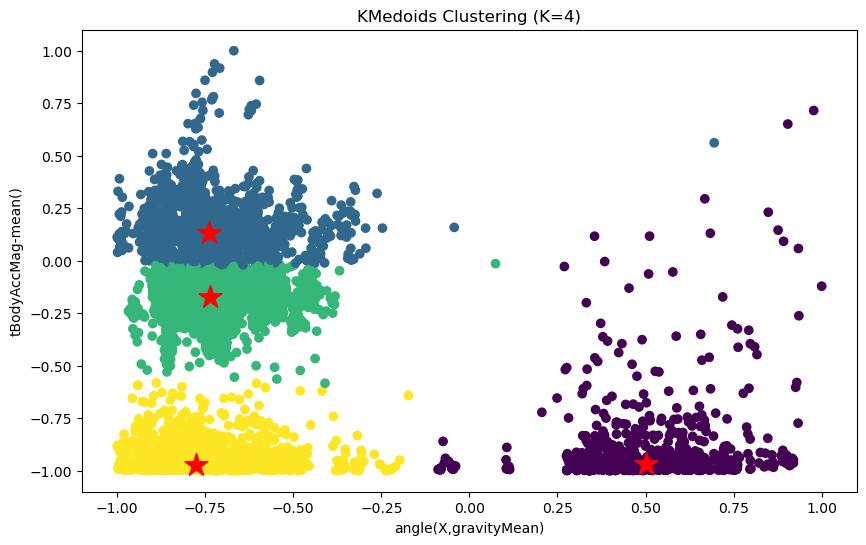

KMeans Cluster:
[[-0.82881479 -0.95726669]
 [-0.72389863  0.17073908]
 [ 0.5133808  -0.93624725]
 [-0.55787319 -0.9648688 ]
 [-0.72093822 -0.17505325]]
204.06435100387108


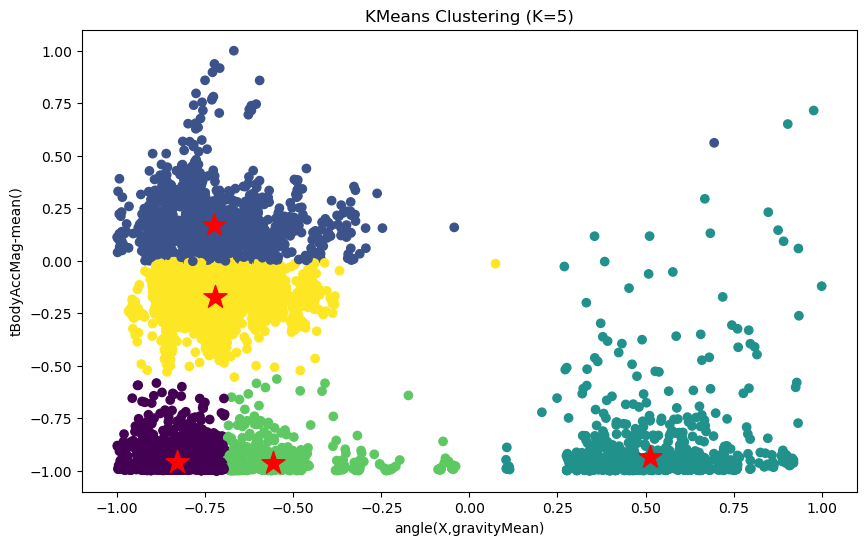


KMedoids Cluster:
[[-0.78751418 -0.18694099]
 [-0.5771859  -0.11703889]
 [ 0.50190453 -0.96669875]
 [-0.77583114 -0.97300944]
 [-0.75577641  0.14755443]]
984.0278285779267


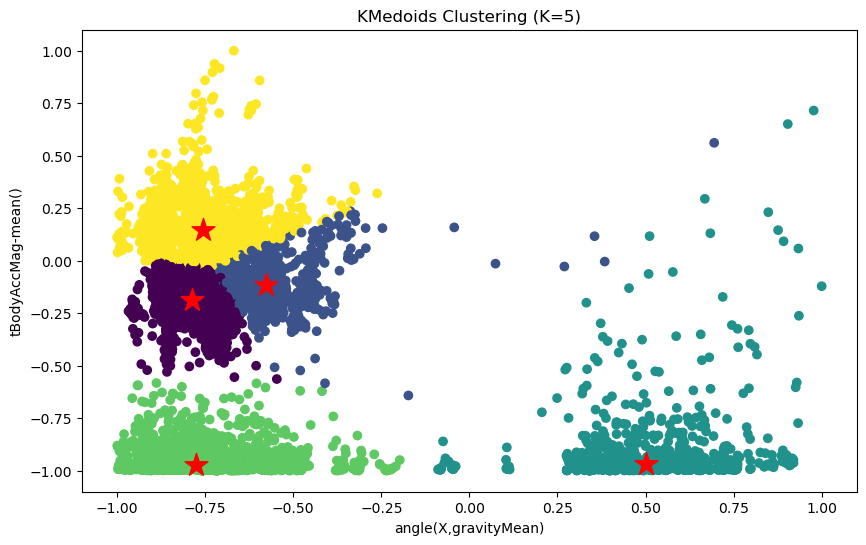

KMeans Cluster:
[[-0.82873789 -0.95727829]
 [-0.54108494 -0.0771249 ]
 [ 0.51315231 -0.94058418]
 [-0.55762816 -0.96434757]
 [-0.77851419 -0.18588993]
 [-0.76200971  0.19198613]]
178.3263128727582


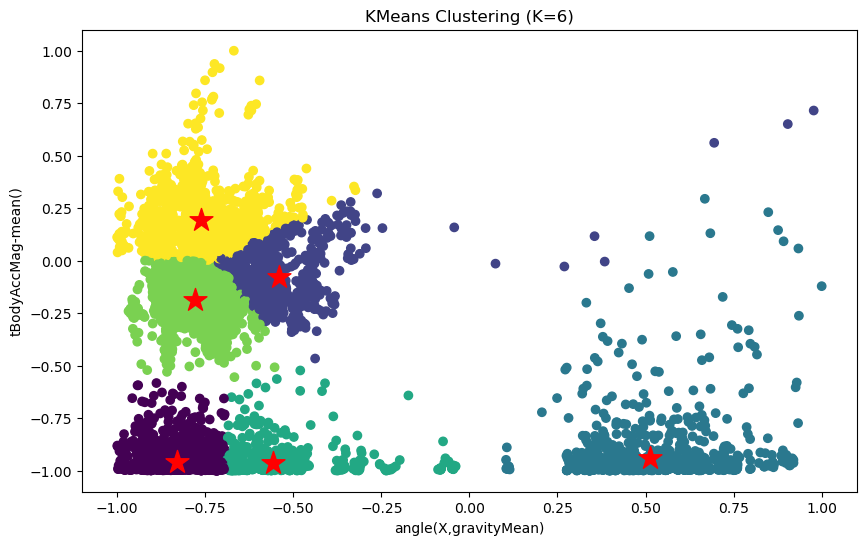


KMedoids Cluster:
[[-0.776171   -0.22836758]
 [-0.57128539 -0.12022428]
 [ 0.50190453 -0.96669875]
 [-0.77583114 -0.97300944]
 [-0.74565306  0.21766593]
 [-0.78322746 -0.02252179]]
928.8269159837553


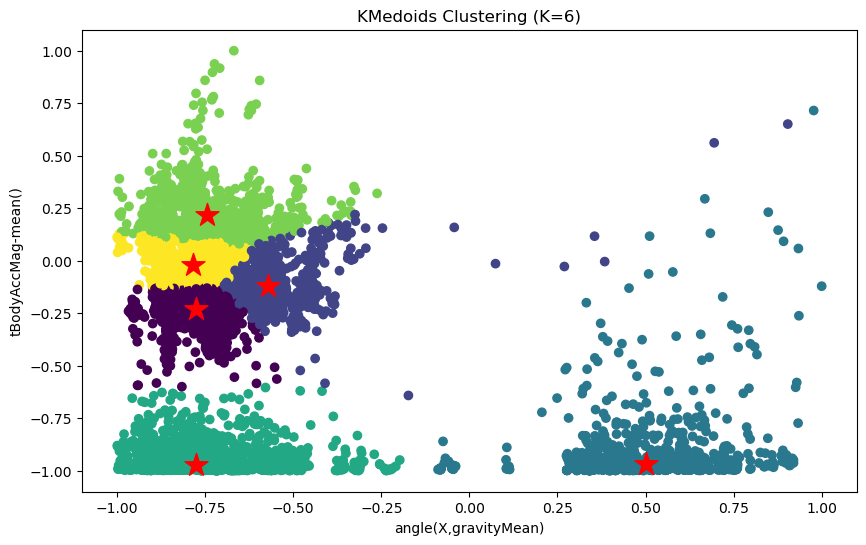

KMeans Cluster:
[[-0.82870383 -0.95749221]
 [-0.52540532 -0.08490312]
 [ 0.51315349 -0.94133271]
 [-0.55771707 -0.9648542 ]
 [-0.77165063 -0.23023912]
 [-0.78047771  0.02205097]
 [-0.73848287  0.29348706]]
160.50362968533284


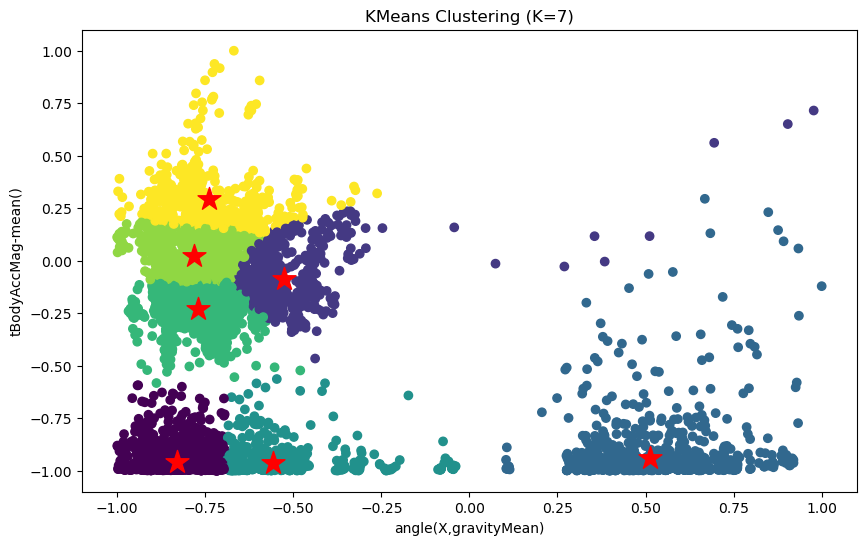


KMedoids Cluster:
[[-0.776171   -0.22836758]
 [-0.57128539 -0.12022428]
 [-0.64788174 -0.97820457]
 [-0.84849941 -0.97173485]
 [ 0.50190453 -0.96669875]
 [-0.78322746 -0.02252179]
 [-0.74565306  0.21766593]]
807.3205933789958


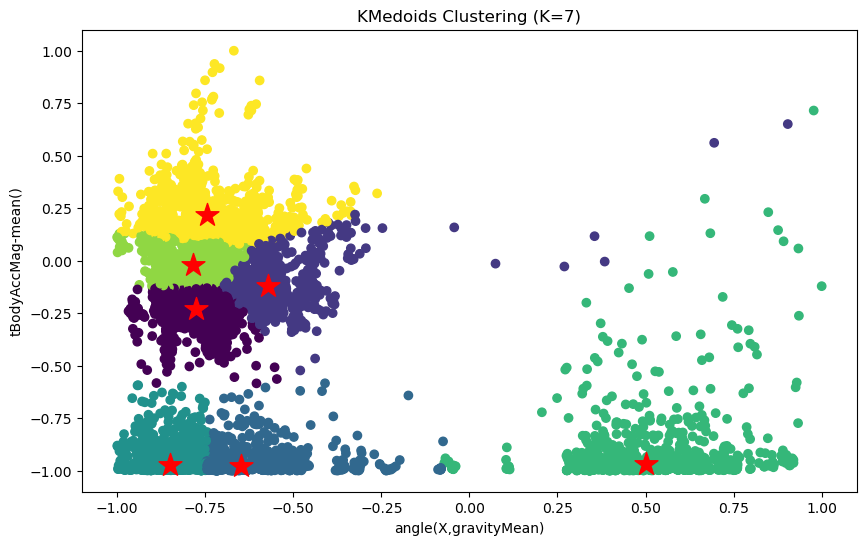

KMeans Cluster:
[[-0.85181505 -0.9552001 ]
 [-0.52560355 -0.08499075]
 [ 0.51749289 -0.94093404]
 [-0.738048    0.29213568]
 [-0.77165461 -0.23169374]
 [-0.64774086 -0.96553817]
 [-0.7807295   0.02007722]
 [-0.21589381 -0.96997023]]
143.92995511546795


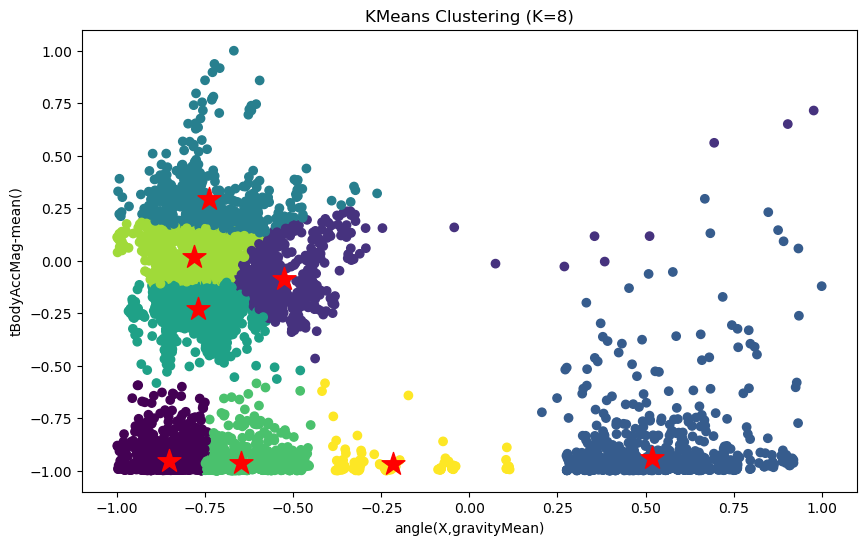


KMedoids Cluster:
[[-0.55497732  0.10501907]
 [-0.74106923 -0.33249083]
 [-0.78631846  0.26629746]
 [-0.58214228 -0.15565725]
 [-0.79289382 -0.17349356]
 [ 0.50190453 -0.96669875]
 [-0.77551332  0.00766563]
 [-0.77583114 -0.97300944]]
867.8457768324884


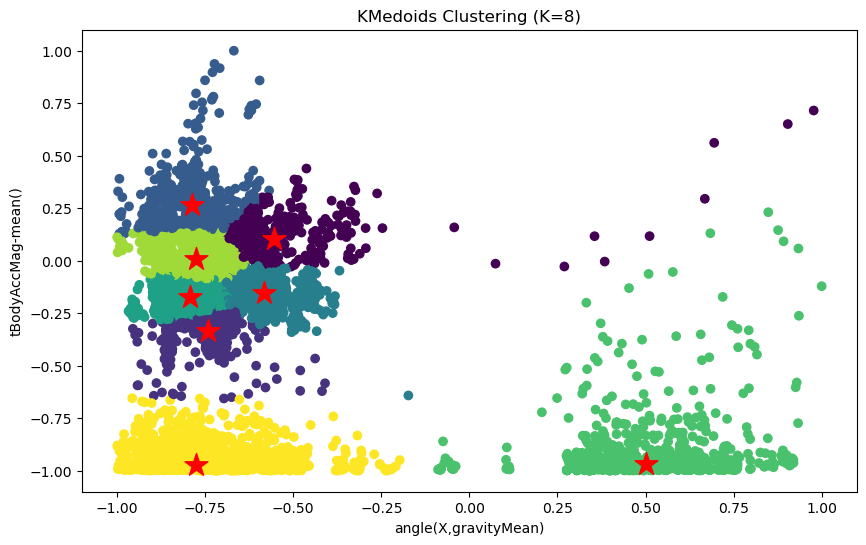

KMeans Cluster:
[[-0.85176923 -0.95545226]
 [-0.50827483 -0.01934   ]
 [ 0.51738495 -0.94181863]
 [-0.75442395  0.33623815]
 [-0.79527755 -0.15309164]
 [-0.64790762 -0.96657215]
 [-0.77535922  0.0752318 ]
 [-0.21457409 -0.97259918]
 [-0.67912691 -0.29055891]]
135.3391168884346


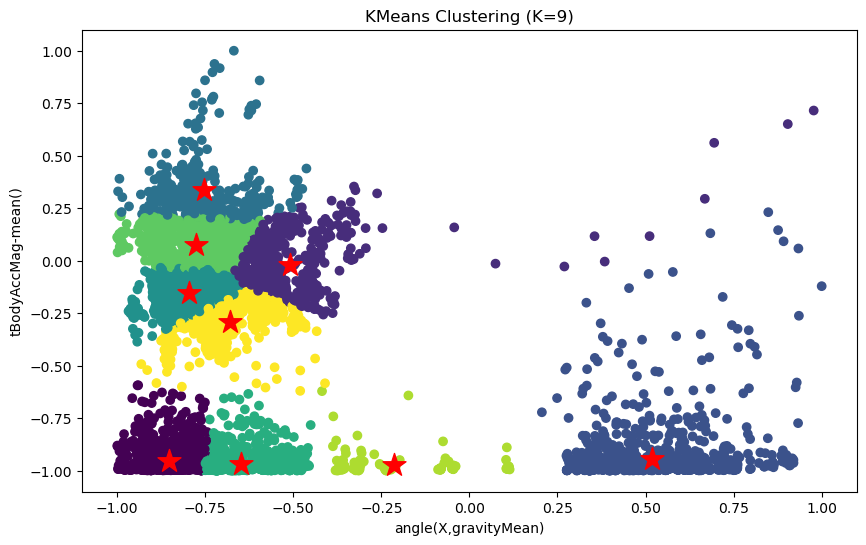


KMedoids Cluster:
[[-0.57266705  0.11435539]
 [-0.73520408 -0.33084347]
 [-0.78631846  0.26629746]
 [-0.56741958 -0.15661756]
 [-0.75338292 -0.15094665]
 [ 0.50190453 -0.96669875]
 [-0.7805104   0.01914476]
 [-0.77583114 -0.97300944]
 [-0.85158952 -0.20177767]]
850.1996389474272


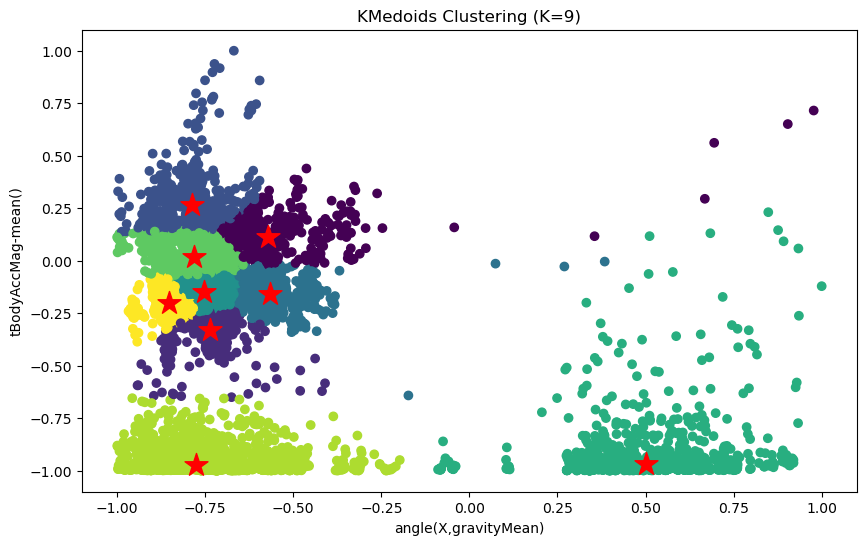

KMeans Cluster:
[[-0.85176923 -0.95545226]
 [-0.53834574 -0.05180777]
 [ 0.51416746 -0.9605322 ]
 [-0.74569235  0.3342067 ]
 [-0.7957544  -0.15124752]
 [-0.64790762 -0.96657215]
 [-0.77588657  0.07820906]
 [-0.21457409 -0.97259918]
 [-0.6978159  -0.30611944]
 [ 0.60828818 -0.21656655]]
110.29257576306044


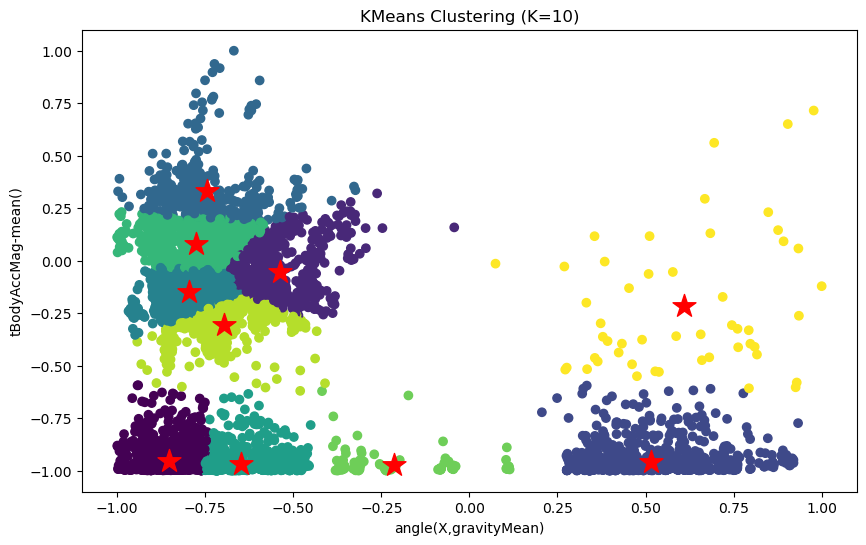


KMedoids Cluster:
[[-0.57266705  0.11435539]
 [-0.74140599 -0.35374914]
 [-0.78631846  0.26629746]
 [-0.5580311  -0.14683984]
 [-0.68890993 -0.18145913]
 [ 0.50190453 -0.96669875]
 [-0.77551332  0.00766563]
 [-0.84849941 -0.97173485]
 [-0.8082704  -0.17839052]
 [-0.64788174 -0.97820457]]
732.3293865260579


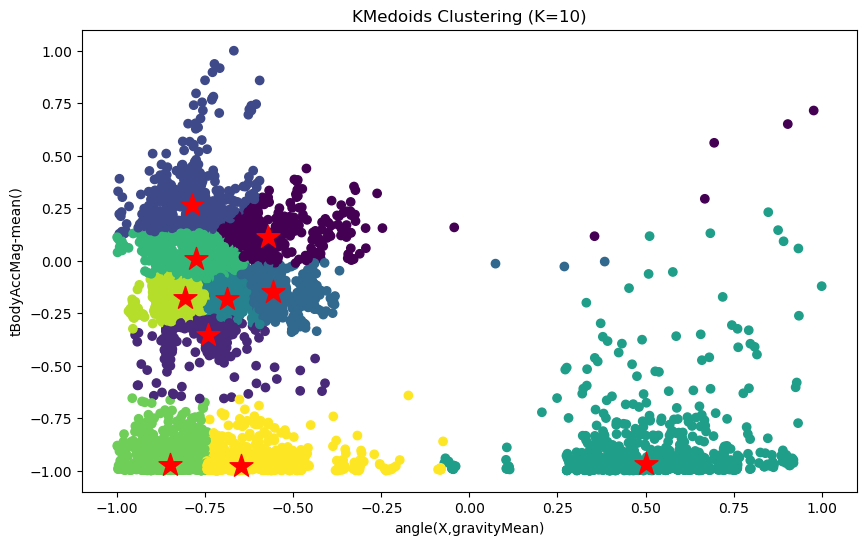

In [25]:
for k in range(2, 11):
    Kmeans_cluster_n(k, features_scaled, new_data)

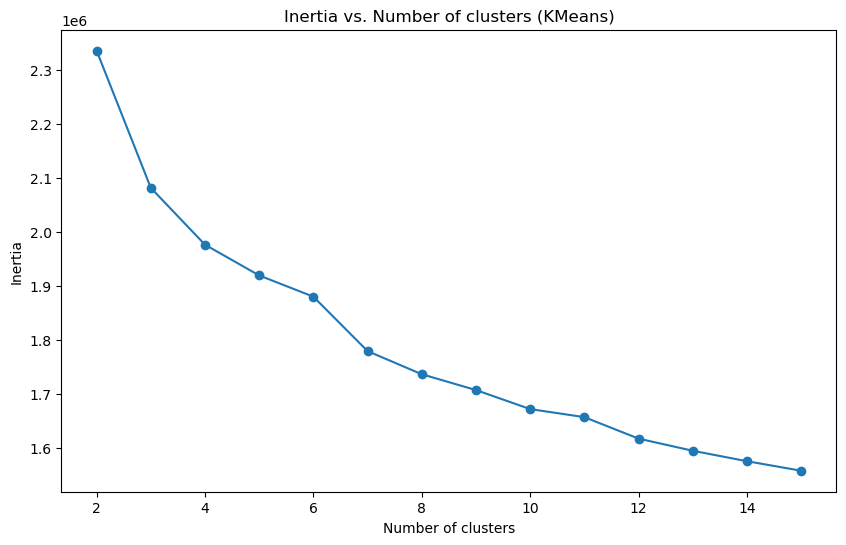

In [29]:
inertia = []

def Kmeans_cluster(n, features_scaled):
    # KMeans clustering
    kmeans_cluster = KMeans(n_clusters= n, random_state= 22, n_init='auto').fit(features_scaled)
    inertia.append(kmeans_cluster.inertia_)

test_range = range(2, 16) # test for 1<K<15
for i in test_range:
    Kmeans_cluster(i, features_scaled)

# plot inertia against the number of clusters
plt.figure(figsize=(10,6))
plt.plot(test_range, inertia, marker='o')
plt.title('Inertia vs. Number of clusters (KMeans)')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

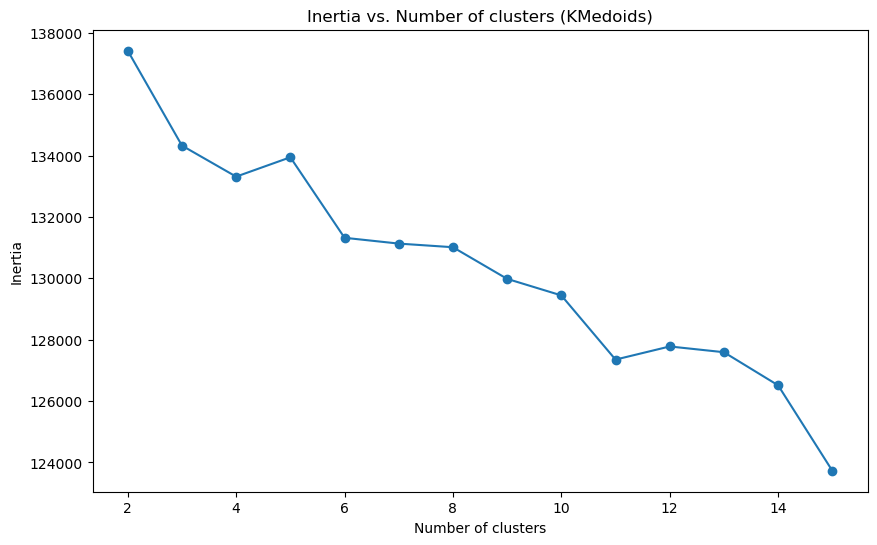

In [30]:
inertia = []

def Kmedoids_cluster(n, features_scaled):
    # KMedoids clustering
    kmedoid_cluster = KMedoids(n_clusters= n, random_state= 22).fit(features_scaled)
    inertia.append(kmedoid_cluster.inertia_)

test_range = range(2, 16) # test for 1<K<15
for i in test_range:
    Kmedoids_cluster(i, features_scaled)

# plot inertia against the number of clusters
plt.figure(figsize=(10,6))
plt.plot(test_range, inertia, marker='o')
plt.title('Inertia vs. Number of clusters (KMedoids)')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

### Computing inertia, evaluate and compare the performance of the scenarios described in sections 4 and 5

The inertia (sum of squared distance of samples to their closest cluster center) decreases as the the number of clusters increases. This is a reasonable observation because there are more centers to be choose for the closest center to a specific data points. The data is fragmental as the cluster increases and no longer reflect the actual data.

### Discuss which K value is the best to choose. Bring reasons to support your idea

Based on the actual data of which data points and their representation of activities, the cluster of 4 is the optimal since it give the closest answer to the actual data representation. Since walking data is messy and they blend into each other a lot, but can be generalize into just walking. The stting and standing data is reflected quite accurate based on the "KMeans Clustering (K=4)".

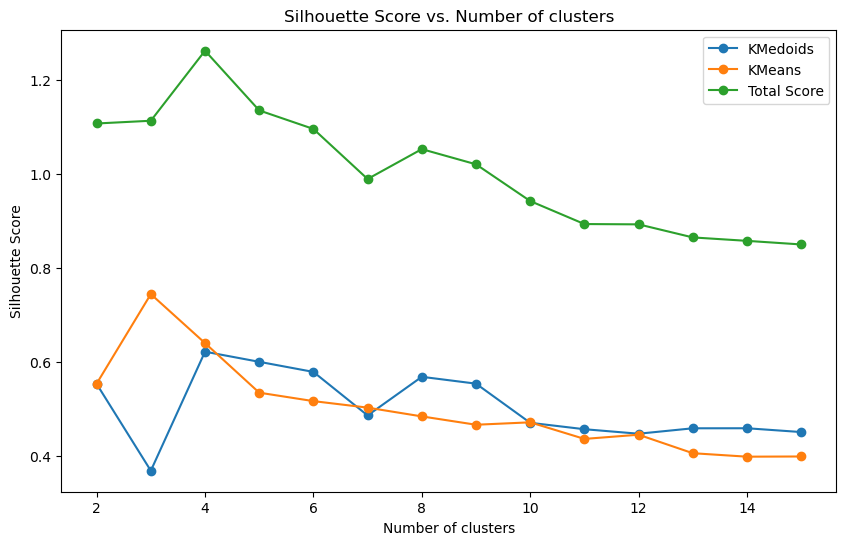

In [31]:
# function returns WSS score for k values from 2 to 15
sil_total = [0] * len(test_range) # Initialize sil_total with zeros

def evaluate_cluster_KMedoids(points, kmax):
    sil = []
    for k in range(2, kmax + 1):
        kmedoids = KMedoids(n_clusters=k, random_state=22).fit(points)
        labels = kmedoids.labels_
        sil.append(silhouette_score(new_data.values, labels, metric='euclidean'))
        sil_total[k - 2] += sil[-1] # Correctly accumulate the score
    return sil

def evaluate_cluster_KMean(points, kmax):
    sil = []
    for k in range(2, kmax + 1):
        kmeans = KMeans(n_clusters=k, random_state=22, n_init='auto').fit(points)
        labels = kmeans.labels_
        sil.append(silhouette_score(new_data.values, labels, metric='euclidean'))
        sil_total[k - 2] += sil[-1] # Correctly accumulate the score
    return sil

# Calculate Silhouette scores
sil_kmedoids = evaluate_cluster_KMedoids(new_data.values, 15)
sil_kmeans = evaluate_cluster_KMean(new_data.values, 15)

# plot silhouette score against the number of clusters with two data on the same plot
plt.figure(figsize=(10, 6))
plt.plot(test_range, sil_kmedoids, marker='o', label='KMedoids')
plt.plot(test_range, sil_kmeans, marker='o', label='KMeans')
plt.plot(test_range, sil_total, marker='o', label='Total Score')
plt.title('Silhouette Score vs. Number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.legend()
plt.show()

### Discuss which K value is the best to choose for both models. Bring reasons to support your idea

Given the benchmark for Silhoutte score, the highest score is the most optimal cluster for each model. The K-means has the highest score at K=3 with about 0.75 score, which means the data is well-separate (walking, station, laying). The K-medoid has the highest score when K=4, which has a separation in sitting, standing, laying, walking. Sitting and standing has some overlap so the score drop below 0.70. Based on the total score (individual model's score is about 0.60), the cluster of K=4 is the optimal for both models and it also implies there are data overlap in the dataset, such as sitting and standing.

#### Silhoutte score benchmark

- 0.70 to 1.00: Indicates a very good clustering configuration with well-separated clusters.
- 0.50 to 0.70: Suggests that the clustering is moderate; while some clusters are distinguished, there may still be some overlaps.
- 0.25 to 0.50: Implies poor clustering, suggesting that many items may be classified incorrectly or clusters may be overlapping excessively.
- Below 0.25: Indicates a very poor clustering situation, often suggesting that the number of clusters may need to be reevaluated or that a different algorithm might yield better results.

Source: [Silhouette Score Benchmark Guide](https://futuremachinelearning.org/understanding-silhouette-score-a-key-metric-for-clustering/)